In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the transaction data we generated
df = pd.read_csv('../data/transactions.csv')

# Quick look at the data
print(f"Total transactions: {len(df)}")
print(f"Normal: {len(df[df['is_anomaly'] == 0])}")
print(f"Anomalous: {len(df[df['is_anomaly'] == 1])}")
print("\nFirst 5 rows:")
df.head()

Total transactions: 1050
Normal: 1000
Anomalous: 50

First 5 rows:


,date,amount,merchant,category,hour_of_day,is_anomaly
0,2024-11-14 18:00:00,20.67,BP Gas,Transport,18,0
1,2024-09-17 17:00:00,46.23,Lyft,Transport,17,0
2,2024-06-17 21:00:00,66.41,PG&E,Utilities,21,0
3,2024-12-24 22:00:00,49.43,Whole Foods,Food,22,0
4,2024-10-12 15:00:00,36.63,BP Gas,Transport,15,0


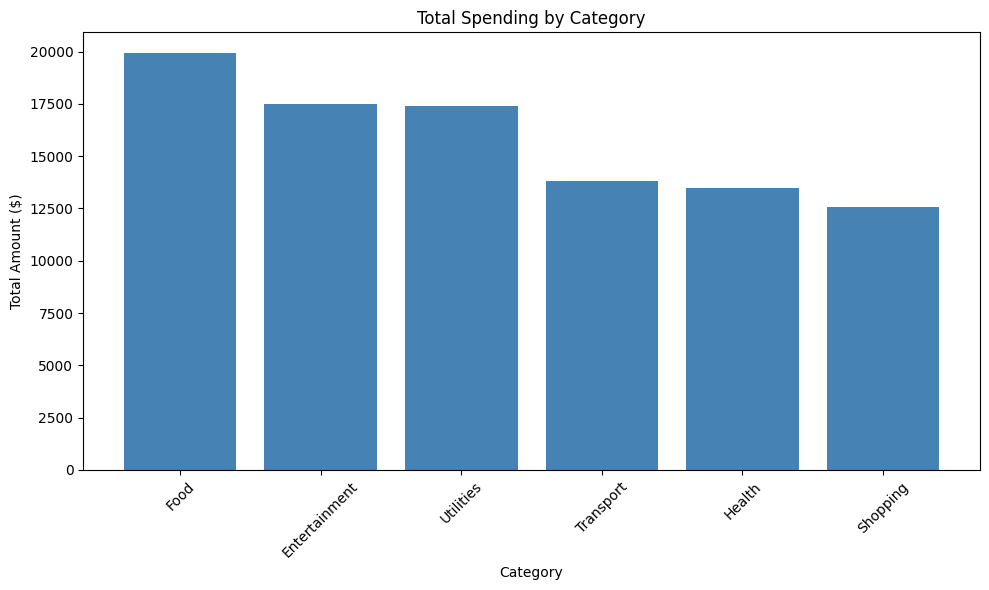

category
Food             19926.16
Entertainment    17498.29
Utilities        17386.60
Transport        13821.47
Health           13467.74
Shopping         12586.28
Name: amount, dtype: float64


In [2]:
# ============================================
# CHART 1 — Spending by category
# Shows which categories we spend the most in
# ============================================

# Group by category and sum the amounts
spending_by_category = df.groupby('category')['amount'].sum().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(spending_by_category.index, spending_by_category.values, color='steelblue')
plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(spending_by_category)

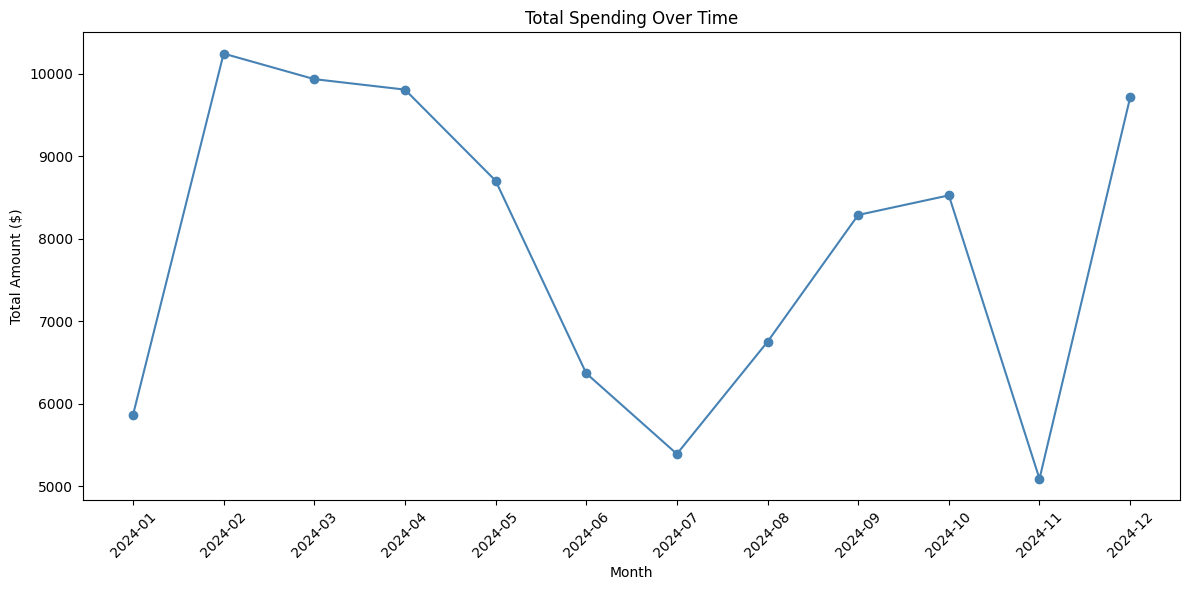

In [3]:
# ============================================
# CHART 2 — Spending over time
# Shows how spending changes month by month
# ============================================

# Convert date column to datetime so we can group by month
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

# Group by month and sum amounts
spending_by_month = df.groupby('month')['amount'].sum()

# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(spending_by_month.index.astype(str), spending_by_month.values, 
         color='steelblue', marker='o')
plt.title('Total Spending Over Time')
plt.xlabel('Month')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

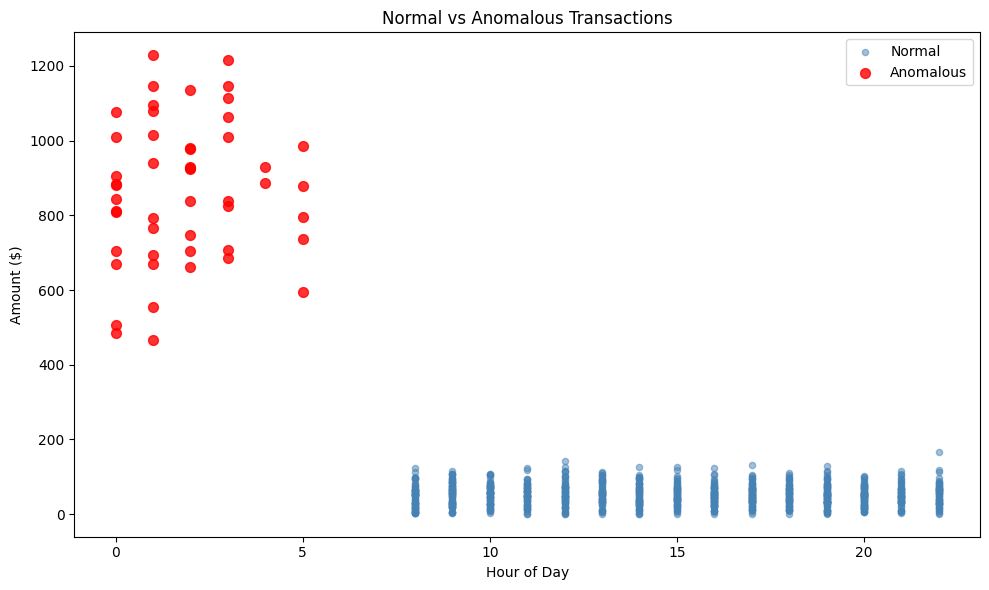

In [4]:
# ============================================
# CHART 3 — Normal vs Anomalous
# This shows WHY isolation forest can detect anomalies
# — they look clearly different from normal transactions
# ============================================

plt.figure(figsize=(10, 6))

# Plot normal transactions in blue
normal = df[df['is_anomaly'] == 0]
anomalous = df[df['is_anomaly'] == 1]

plt.scatter(normal['hour_of_day'], normal['amount'], 
            color='steelblue', alpha=0.5, label='Normal', s=20)
plt.scatter(anomalous['hour_of_day'], anomalous['amount'], 
            color='red', alpha=0.8, label='Anomalous', s=50)

plt.title('Normal vs Anomalous Transactions')
plt.xlabel('Hour of Day')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# ============================================
# BASIC STATS
# Understanding the numbers behind the data
# ============================================
print("=== NORMAL TRANSACTIONS ===")
print(normal['amount'].describe())

print("\n=== ANOMALOUS TRANSACTIONS ===")
print(anomalous['amount'].describe())

=== NORMAL TRANSACTIONS ===
count    1000.00000
mean       51.41503
std        27.88750
min         1.00000
25%        30.81500
50%        50.76000
75%        69.43750
max       165.58000
Name: amount, dtype: float64

=== ANOMALOUS TRANSACTIONS ===
count      50.00000
mean      865.43020
std       190.43477
min       466.28000
25%       715.14750
50%       879.27000
75%      1003.29750
max      1228.45000
Name: amount, dtype: float64
